# Projeto Parte II: Classificação Direcional Multivariada
# Teste 1: Baseline Puro (LSTM Simples + OHLCV)

**Premissa:** O objetivo preditivo foi alterado da estimação contínua de preços (Regressão) para a previsão discreta de movimento (Classificação Binária: $1$ para Alta, $0$ para Baixa). Este primeiro teste estabelece o "Baseline" (linha de base) de acurácia direcional utilizando a arquitetura mais elementar e os dados brutos de mercado.

**Configuração do Experimento:**
* **Dados (Features):** 20 atributos (Apenas Preço de Abertura, Alta, Baixa, Fechamento e Volume) para os 4 ativos.
* **Janela Temporal (seq_len):** 60 dias úteis.
* **Arquitetura Base:** Rede LSTM Simples (64 neurônios na camada oculta).
* **Camada de Saída:** Função de Ativação Sigmoide ($\sigma(x) = \frac{1}{1 + e^{-x}}$).
* **Função de Custo (Loss):** Entropia Cruzada Binária (BCELoss).
* **Validação:** Média global após o treinamento de um *Ensemble* de 100 redes neurais independentes.

Hardware ativado para Classificação: cuda
Base de dados criada com 20 variáveis (Baseline Puro).

Treinando 100 modelos classificadores (LSTM 64 neurônios)...
  - 20/100 modelos concluídos.
  - 40/100 modelos concluídos.
  - 60/100 modelos concluídos.
  - 80/100 modelos concluídos.
  - 100/100 modelos concluídos.

 RESULTADO CLASSIFICADOR BASELINE PURO (100 REDES)
Acurácia Microsoft (MSFT): 53.82%
Acurácia Nvidia (NVDA): 52.35%
Acurácia Alphabet (GOOGL): 55.00%
Acurácia Meta Platforms (META): 51.47%
--------------------------------------------------
ACURÁCIA GLOBAL DO PORTFÓLIO: 53.16%


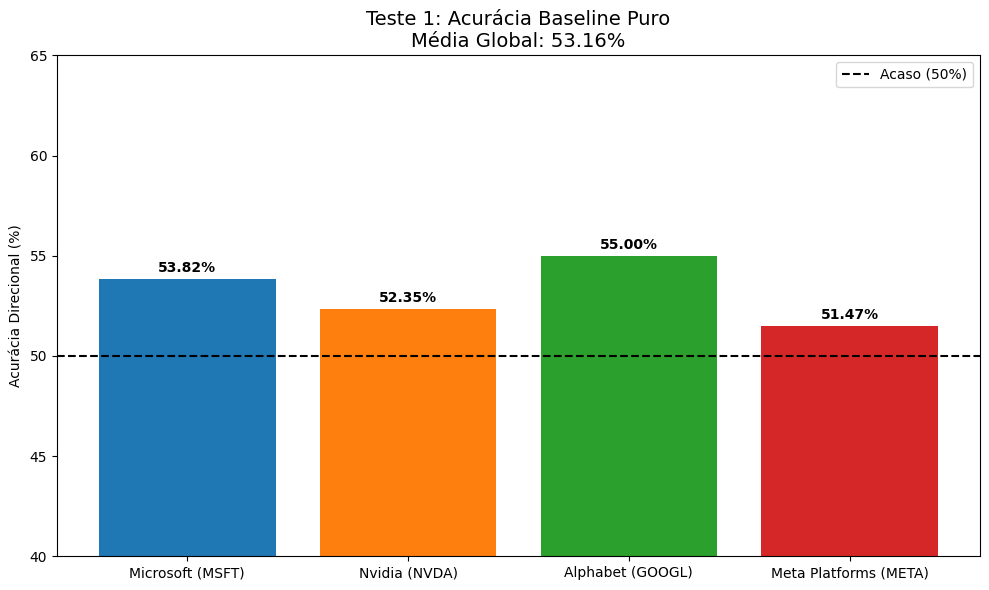

: 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware ativado para Classificação: {device}")

# 1. Extração de Dados (Apenas OHLCV - 20 variáveis)
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()

# Colocamos os fechamentos (nossos alvos de análise) nas 4 primeiras colunas
for ativo in tickers:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

for ativo in tickers:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]

df = df.dropna()
QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

print(f"Base de dados criada com {QTD_FEATURES} variáveis (Baseline Puro).")

# 2. Normalização e Criação de Alvos Binários (1 = Sobe, 0 = Cai)
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

seq_len = 60 

def criar_sequencias_classificacao(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        
        # O preço real de "hoje" (o último dia dentro da sequência X)
        preco_hoje = dados_array[i-1, 0:QTD_ALVOS]
        # O preço de "amanhã" (o dia que queremos prever)
        preco_amanha = dados_array[i, 0:QTD_ALVOS]
        
        # A Mágica da Classificação: Se amanhã > hoje, vira 1. Senão, 0.
        alvo_binario = (preco_amanha > preco_hoje).astype(np.float32)
        y.append(alvo_binario)
        
    return np.array(X), np.array(y)

X, y = criar_sequencias_classificacao(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesClassificationDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesClassificationDataset(X_test, y_test), batch_size=32)

# 3. Arquitetura do Classificador (Com Sigmoide)
class Classificador_Baseline_Multi(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Classificador_Baseline_Multi, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid() # Transforma a saída em probabilidades (0 a 1)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        logits = self.fc(saida_lstm[:, -1, :])
        return self.sigmoid(logits)

# 4. A Maratona de 100 Testes (Ensemble)
N_RODADAS = 100 
todas_previsoes_probabilidades = []

print(f"\nTreinando {N_RODADAS} modelos classificadores (LSTM 64 neurônios)...")

for rodada in range(N_RODADAS):
    modelo = Classificador_Baseline_Multi(input_size=QTD_FEATURES, hidden_size=64, output_size=QTD_ALVOS).to(device)
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)
    
    # ATENÇÃO: Mudança da Função de Perda para BCELoss
    criterion = nn.BCELoss() 
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            probabilidades = modelo(pacotes_X.to(device))
            erro = criterion(probabilidades, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    probabilidades_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            probabilidades_modelo.extend(chute.cpu().numpy())
            
    todas_previsoes_probabilidades.append(probabilidades_modelo)
    
    if (rodada + 1) % 20 == 0:
        print(f"  - {rodada+1}/{N_RODADAS} modelos concluídos.")

# 5. Cálculo da Acurácia Final (Hit Rate Binário)
media_probabilidades = np.mean(todas_previsoes_probabilidades, axis=0)

# Se a probabilidade for maior que 50% (0.5), o modelo votou que vai Subir (1)
previsoes_finais_binarias = (media_probabilidades >= 0.5).astype(int)
alvos_reais_binarios = y_test.astype(int)

acuracias = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*50)
print(" RESULTADO CLASSIFICADOR BASELINE PURO (100 REDES)")
print("="*50)

for i in range(QTD_ALVOS):
    acertos = np.sum(previsoes_finais_binarias[:, i] == alvos_reais_binarios[:, i])
    total = len(alvos_reais_binarios[:, i])
    acuracia = (acertos / total) * 100
    acuracias.append(acuracia)
    print(f"Acurácia {nomes_ativos[i]}: {acuracia:.2f}%")

print("-" * 50)
print(f"ACURÁCIA GLOBAL DO PORTFÓLIO: {np.mean(acuracias):.2f}%")
print("="*50)

# 6. Painel Gráfico de Desempenho
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(nomes_ativos, acuracias, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

# Adiciona a linha de 50% (o cara e coroa do mercado)
ax.axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='Acaso (50%)')

ax.set_ylabel('Acurácia Direcional (%)')
ax.set_title(f'Teste 1: Acurácia Baseline Puro\nMédia Global: {np.mean(acuracias):.2f}%', fontsize=14)
ax.set_ylim(40, 65) # Focado na zona de interesse financeiro

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# Teste 2: Classificador Multivariado (Engenharia de Atributos Simultânea)

**Premissa:** O Baseline puro alcançou 53.16% de acurácia direcional utilizando apenas o histórico cru. O objetivo deste teste é avaliar como a rede classificadora reage ao aumento drástico da dimensionalidade dos dados (inserção de indicadores de momento e contexto macroeconômico).

**Configuração do Experimento:**
* **Dados (Features):** 50 atributos (OHLCV + RSI, MACD, BB, S&P 500, VIX) para os 4 ativos.
* **Janela Temporal:** 60 dias úteis.
* **Arquitetura Base:** LSTM Simples (64 neurônios).
* **Validação:** Ensemble de 100 redes neurais.

Hardware ativado para Classificador Megazord: cuda
Base de dados expandida com sucesso para 50 variáveis.

Treinando 100 modelos classificadores (50 Variáveis)...
  - 20/100 modelos concluídos.
  - 40/100 modelos concluídos.
  - 60/100 modelos concluídos.
  - 80/100 modelos concluídos.
  - 100/100 modelos concluídos.

 RESULTADO CLASSIFICADOR MEGAZORD (100 REDES)
Acurácia Microsoft (MSFT): 55.79%
Acurácia Nvidia (NVDA): 54.90%
Acurácia Alphabet (GOOGL): 54.90%
Acurácia Meta Platforms (META): 53.12%
--------------------------------------------------
ACURÁCIA GLOBAL DO PORTFÓLIO: 54.67%


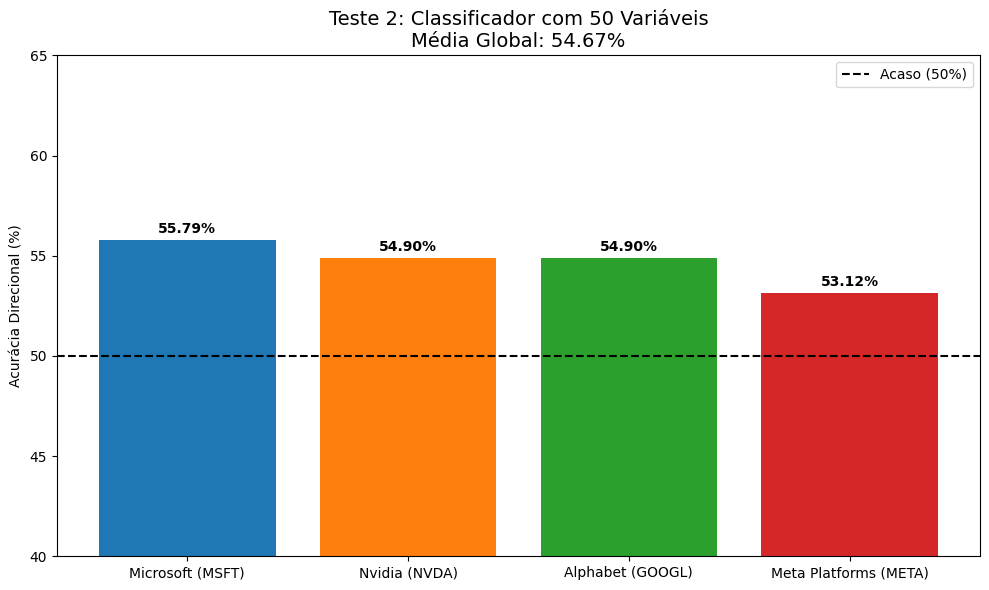

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware ativado para Classificador Megazord: {device}")

# 1. Coleta de Dados e Criação das 50 Variáveis
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
ativos = ['MSFT', 'NVDA', 'GOOGL', 'META']

# Alvos (Fechamentos) nas primeiras posições
for ativo in ativos:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

for ativo in ativos:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]

    close_ativo = df[f'{ativo}_Close']
    df[f'{ativo}_SMA_20'] = close_ativo.rolling(window=20).mean()
    df[f'{ativo}_EMA_20'] = close_ativo.ewm(span=20, adjust=False).mean()

    delta = close_ativo.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'{ativo}_RSI_14'] = 100 - (100 / (1 + (gain / loss)))

    exp1 = close_ativo.ewm(span=12, adjust=False).mean()
    exp2 = close_ativo.ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    df[f'{ativo}_MACD'] = macd
    df[f'{ativo}_MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()

    std_20 = close_ativo.rolling(window=20).std()
    df[f'{ativo}_BB_Upper'] = df[f'{ativo}_SMA_20'] + (std_20 * 2)
    df[f'{ativo}_BB_Lower'] = df[f'{ativo}_SMA_20'] - (std_20 * 2)

df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df = df.dropna()
QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

print(f"Base de dados expandida com sucesso para {QTD_FEATURES} variáveis.")

# 2. Normalização e Preparação das Sequências
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

seq_len = 60 

def criar_sequencias_classificacao(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        preco_hoje = dados_array[i-1, 0:QTD_ALVOS]
        preco_amanha = dados_array[i, 0:QTD_ALVOS]
        alvo_binario = (preco_amanha > preco_hoje).astype(np.float32)
        y.append(alvo_binario)
    return np.array(X), np.array(y)

X, y = criar_sequencias_classificacao(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesClassificationDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesClassificationDataset(X_test, y_test), batch_size=32)

# 3. Arquitetura do Classificador
class Classificador_Baseline_Multi(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Classificador_Baseline_Multi, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        logits = self.fc(saida_lstm[:, -1, :])
        return self.sigmoid(logits)

# 4. A Maratona de 100 Testes
N_RODADAS = 100 
todas_previsoes_probabilidades = []

print(f"\nTreinando {N_RODADAS} modelos classificadores (50 Variáveis)...")

for rodada in range(N_RODADAS):
    modelo = Classificador_Baseline_Multi(input_size=QTD_FEATURES, hidden_size=64, output_size=QTD_ALVOS).to(device)
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)
    criterion = nn.BCELoss() 
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            probabilidades = modelo(pacotes_X.to(device))
            erro = criterion(probabilidades, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    probabilidades_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            probabilidades_modelo.extend(chute.cpu().numpy())
            
    todas_previsoes_probabilidades.append(probabilidades_modelo)
    
    if (rodada + 1) % 20 == 0:
        print(f"  - {rodada+1}/{N_RODADAS} modelos concluídos.")

# 5. Cálculo da Acurácia Final
media_probabilidades = np.mean(todas_previsoes_probabilidades, axis=0)
previsoes_finais_binarias = (media_probabilidades >= 0.5).astype(int)
alvos_reais_binarios = y_test.astype(int)

acuracias = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*50)
print(" RESULTADO CLASSIFICADOR MEGAZORD (100 REDES)")
print("="*50)

for i in range(QTD_ALVOS):
    acertos = np.sum(previsoes_finais_binarias[:, i] == alvos_reais_binarios[:, i])
    total = len(alvos_reais_binarios[:, i])
    acuracia = (acertos / total) * 100
    acuracias.append(acuracia)
    print(f"Acurácia {nomes_ativos[i]}: {acuracia:.2f}%")

print("-" * 50)
print(f"ACURÁCIA GLOBAL DO PORTFÓLIO: {np.mean(acuracias):.2f}%")
print("="*50)

# 6. Painel Gráfico de Desempenho
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_ativos, acuracias, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='Acaso (50%)')
ax.set_ylabel('Acurácia Direcional (%)')
ax.set_title(f'Teste 2: Classificador com 50 Variáveis\nMédia Global: {np.mean(acuracias):.2f}%', fontsize=14)
ax.set_ylim(40, 65) 

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# Teste 3: Arquitetura Suprema de Classificação (Bi-LSTM + Bi-GRU + Dropout)

**Premissa:** O modelo classificador demonstrou excelente sinergia com o ecossistema de 50 variáveis (Teste 2), elevando a acurácia global. Para extrair o máximo de capacidade de abstração não-linear desses dados multivariados, aplicaremos a topologia profunda que obteve o melhor desempenho estrutural em testes anteriores.

**Configuração do Experimento:**
* **Dados (Features):** 50 atributos.
* **Janela Temporal:** 60 dias úteis.
* **Topologia:** Bi-LSTM (128) -> Dropout (0.2) -> Bi-GRU (64) -> Dropout (0.2) -> Linear (4).
* **Camada de Saída:** Sigmoide (Probabilidade Direcional).
* **Validação:** Ensemble de 100 redes neurais independentes.

Hardware ativado para Arquitetura Suprema de Classificação: cuda

Treinando 100 modelos da Arquitetura Suprema (Bi-LSTM + Bi-GRU + Dropout)...
  - 20/100 modelos concluídos.
  - 40/100 modelos concluídos.
  - 60/100 modelos concluídos.
  - 80/100 modelos concluídos.
  - 100/100 modelos concluídos.

 RESULTADO DA ARQUITETURA SUPREMA (100 REDES)
Acurácia Microsoft (MSFT): 51.63%
Acurácia Nvidia (NVDA): 54.01%
Acurácia Alphabet (GOOGL): 54.30%
Acurácia Meta Platforms (META): 51.93%
--------------------------------------------------
ACURÁCIA GLOBAL DO PORTFÓLIO: 52.97%


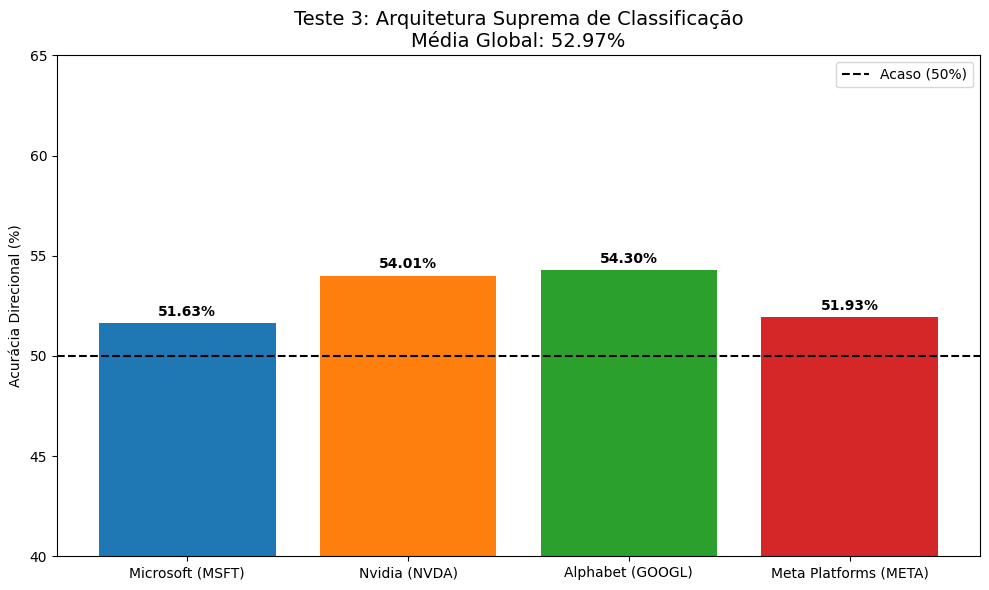

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware ativado para Arquitetura Suprema de Classificação: {device}")

# 1. Coleta de Dados e Criação das 50 Variáveis
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
ativos = ['MSFT', 'NVDA', 'GOOGL', 'META']

for ativo in ativos:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

for ativo in ativos:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]

    close_ativo = df[f'{ativo}_Close']
    df[f'{ativo}_SMA_20'] = close_ativo.rolling(window=20).mean()
    df[f'{ativo}_EMA_20'] = close_ativo.ewm(span=20, adjust=False).mean()

    delta = close_ativo.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'{ativo}_RSI_14'] = 100 - (100 / (1 + (gain / loss)))

    exp1 = close_ativo.ewm(span=12, adjust=False).mean()
    exp2 = close_ativo.ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    df[f'{ativo}_MACD'] = macd
    df[f'{ativo}_MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()

    std_20 = close_ativo.rolling(window=20).std()
    df[f'{ativo}_BB_Upper'] = df[f'{ativo}_SMA_20'] + (std_20 * 2)
    df[f'{ativo}_BB_Lower'] = df[f'{ativo}_SMA_20'] - (std_20 * 2)

df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df = df.dropna()
QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

# 2. Normalização e Preparação Binária
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

seq_len = 60 

def criar_sequencias_classificacao(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        preco_hoje = dados_array[i-1, 0:QTD_ALVOS]
        preco_amanha = dados_array[i, 0:QTD_ALVOS]
        alvo_binario = (preco_amanha > preco_hoje).astype(np.float32)
        y.append(alvo_binario)
    return np.array(X), np.array(y)

X, y = criar_sequencias_classificacao(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesClassificationDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesClassificationDataset(X_test, y_test), batch_size=32)

# 3. A Arquitetura Suprema de Classificação
class Classificador_Supremo(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size, dropout_rate=0.2):
        super(Classificador_Supremo, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # A GRU recebe o dobro de tamanho por causa da Bi-LSTM
        self.gru = nn.GRU(hidden_lstm * 2, hidden_gru, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc = nn.Linear(hidden_gru * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_lstm = self.dropout1(saida_lstm)
        
        saida_gru, _ = self.gru(saida_lstm)
        saida_gru = self.dropout2(saida_gru)
        
        logits = self.fc(saida_gru[:, -1, :])
        return self.sigmoid(logits)

# 4. O Teste de 100 Rodadas
N_RODADAS = 100 
todas_previsoes_probabilidades = []

print(f"\nTreinando {N_RODADAS} modelos da Arquitetura Suprema (Bi-LSTM + Bi-GRU + Dropout)...")

for rodada in range(N_RODADAS):
    modelo = Classificador_Supremo(
        input_size=QTD_FEATURES, 
        hidden_lstm=128, 
        hidden_gru=64, 
        output_size=QTD_ALVOS
    ).to(device)
    
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)
    criterion = nn.BCELoss() 
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            probabilidades = modelo(pacotes_X.to(device))
            erro = criterion(probabilidades, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    probabilidades_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            probabilidades_modelo.extend(chute.cpu().numpy())
            
    todas_previsoes_probabilidades.append(probabilidades_modelo)
    
    if (rodada + 1) % 20 == 0:
        print(f"  - {rodada+1}/{N_RODADAS} modelos concluídos.")

# 5. Cálculo das Métricas Direcionais
media_probabilidades = np.mean(todas_previsoes_probabilidades, axis=0)
previsoes_finais_binarias = (media_probabilidades >= 0.5).astype(int)
alvos_reais_binarios = y_test.astype(int)

acuracias = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*50)
print(" RESULTADO DA ARQUITETURA SUPREMA (100 REDES)")
print("="*50)

for i in range(QTD_ALVOS):
    acertos = np.sum(previsoes_finais_binarias[:, i] == alvos_reais_binarios[:, i])
    total = len(alvos_reais_binarios[:, i])
    acuracia = (acertos / total) * 100
    acuracias.append(acuracia)
    print(f"Acurácia {nomes_ativos[i]}: {acuracia:.2f}%")

print("-" * 50)
print(f"ACURÁCIA GLOBAL DO PORTFÓLIO: {np.mean(acuracias):.2f}%")
print("="*50)

# 6. Painel Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_ativos, acuracias, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='Acaso (50%)')
ax.set_ylabel('Acurácia Direcional (%)')
ax.set_title(f'Teste 3: Arquitetura Suprema de Classificação\nMédia Global: {np.mean(acuracias):.2f}%', fontsize=14)
ax.set_ylim(40, 65) 

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# Teste 3 (Corrigido): Aumento de Capacidade Paramétrica (LSTM 128)

**Premissa:** O salto arquitetural prematuro causou uma queda de performance, impedindo a identificação da causa isolada (violação do Estudo de Ablação). Retornamos à topologia do Teste 2 (que obteve 54.67% de acurácia) para testar de forma isolada a expansão da capacidade de processamento da rede.

**Configuração do Experimento:**
* **Dados (Features):** 50 atributos multivariados.
* **Janela Temporal:** 60 dias úteis.
* **Arquitetura Base:** LSTM Simples (128 neurônios).
* **Camada de Saída:** Sigmoide (Probabilidade Direcional).
* **Validação:** Ensemble de 100 redes neurais independentes.

Hardware ativado para Aumento de Capacidade: cuda

Treinando 100 modelos classificadores (LSTM com 128 neurônios)...
  - 20/100 modelos concluídos.
  - 40/100 modelos concluídos.
  - 60/100 modelos concluídos.
  - 80/100 modelos concluídos.
  - 100/100 modelos concluídos.

 RESULTADO DO TESTE 3 CORRIGIDO (100 REDES)
Acurácia Microsoft (MSFT): 52.82%
Acurácia Nvidia (NVDA): 54.01%
Acurácia Alphabet (GOOGL): 55.49%
Acurácia Meta Platforms (META): 52.52%
--------------------------------------------------
ACURÁCIA GLOBAL DO PORTFÓLIO: 53.71%


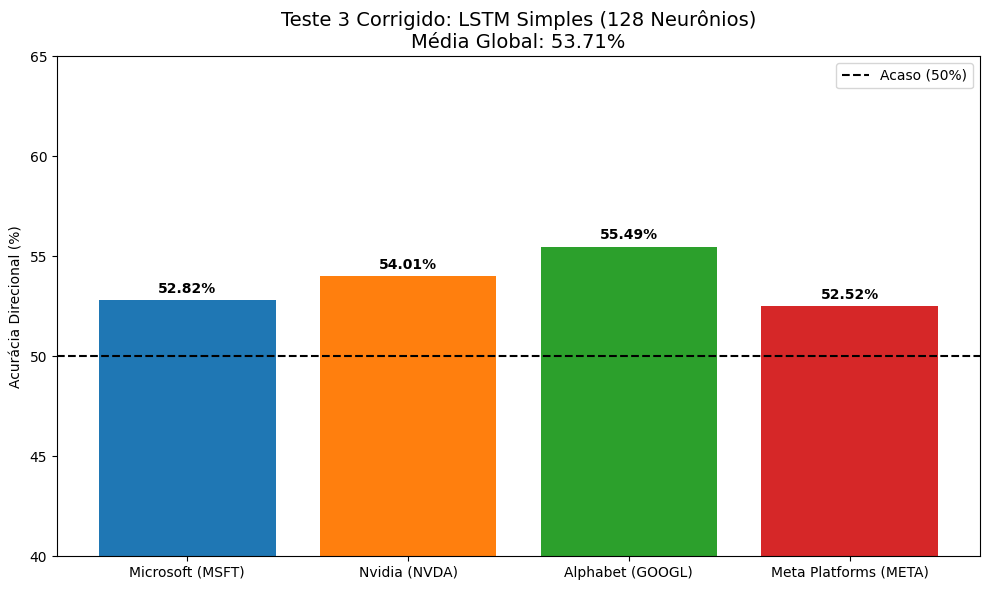

: 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware ativado para Aumento de Capacidade: {device}")

# 1. Coleta de Dados e Criação das 50 Variáveis
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
ativos = ['MSFT', 'NVDA', 'GOOGL', 'META']

for ativo in ativos:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

for ativo in ativos:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]

    close_ativo = df[f'{ativo}_Close']
    df[f'{ativo}_SMA_20'] = close_ativo.rolling(window=20).mean()
    df[f'{ativo}_EMA_20'] = close_ativo.ewm(span=20, adjust=False).mean()

    delta = close_ativo.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'{ativo}_RSI_14'] = 100 - (100 / (1 + (gain / loss)))

    exp1 = close_ativo.ewm(span=12, adjust=False).mean()
    exp2 = close_ativo.ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    df[f'{ativo}_MACD'] = macd
    df[f'{ativo}_MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()

    std_20 = close_ativo.rolling(window=20).std()
    df[f'{ativo}_BB_Upper'] = df[f'{ativo}_SMA_20'] + (std_20 * 2)
    df[f'{ativo}_BB_Lower'] = df[f'{ativo}_SMA_20'] - (std_20 * 2)

df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df = df.dropna()
QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

# 2. Normalização e Preparação Binária
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

seq_len = 60 

def criar_sequencias_classificacao(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        preco_hoje = dados_array[i-1, 0:QTD_ALVOS]
        preco_amanha = dados_array[i, 0:QTD_ALVOS]
        alvo_binario = (preco_amanha > preco_hoje).astype(np.float32)
        y.append(alvo_binario)
    return np.array(X), np.array(y)

X, y = criar_sequencias_classificacao(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesClassificationDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesClassificationDataset(X_test, y_test), batch_size=32)

# 3. Arquitetura Corrigida: Apenas expansão paramétrica
class Classificador_LSTM_Grande(nn.Module):
    def __init__(self, input_size, hidden_lstm, output_size):
        super(Classificador_LSTM_Grande, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True)
        self.fc = nn.Linear(hidden_lstm, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        logits = self.fc(saida_lstm[:, -1, :])
        return self.sigmoid(logits)

# 4. O Teste de 100 Rodadas
N_RODADAS = 100 
todas_previsoes_probabilidades = []

print(f"\nTreinando {N_RODADAS} modelos classificadores (LSTM com 128 neurônios)...")

for rodada in range(N_RODADAS):
    modelo = Classificador_LSTM_Grande(
        input_size=QTD_FEATURES, 
        hidden_lstm=128, 
        output_size=QTD_ALVOS
    ).to(device)
    
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)
    criterion = nn.BCELoss() 
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            probabilidades = modelo(pacotes_X.to(device))
            erro = criterion(probabilidades, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    probabilidades_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            probabilidades_modelo.extend(chute.cpu().numpy())
            
    todas_previsoes_probabilidades.append(probabilidades_modelo)
    
    if (rodada + 1) % 20 == 0:
        print(f"  - {rodada+1}/{N_RODADAS} modelos concluídos.")

# 5. Cálculo das Métricas Direcionais
media_probabilidades = np.mean(todas_previsoes_probabilidades, axis=0)
previsoes_finais_binarias = (media_probabilidades >= 0.5).astype(int)
alvos_reais_binarios = y_test.astype(int)

acuracias = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*50)
print(" RESULTADO DO TESTE 3 CORRIGIDO (100 REDES)")
print("="*50)

for i in range(QTD_ALVOS):
    acertos = np.sum(previsoes_finais_binarias[:, i] == alvos_reais_binarios[:, i])
    total = len(alvos_reais_binarios[:, i])
    acuracia = (acertos / total) * 100
    acuracias.append(acuracia)
    print(f"Acurácia {nomes_ativos[i]}: {acuracia:.2f}%")

print("-" * 50)
print(f"ACURÁCIA GLOBAL DO PORTFÓLIO: {np.mean(acuracias):.2f}%")
print("="*50)

# 6. Painel Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_ativos, acuracias, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='Acaso (50%)')
ax.set_ylabel('Acurácia Direcional (%)')
ax.set_title(f'Teste 3 Corrigido: LSTM Simples (128 Neurônios)\nMédia Global: {np.mean(acuracias):.2f}%', fontsize=14)
ax.set_ylim(40, 65) 

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# Teste 3 (Revisado): Arquitetura Suprema de Classificação com Alta Capacidade

**Premissa:** O teste anterior da topologia profunda (Bi-LSTM + Bi-GRU) falhou devido a um subajuste paramétrico ("gargalo"). A rede não possuía neurônios suficientes (apenas 128) para processar o peso computacional de duas camadas bidirecionais operando sobre 50 variáveis. 

**Objetivo:** Reavaliar a arquitetura complexa fornecendo a capacidade paramétrica adequada (alta densidade de neurônios) para verificar se a rede consegue extrair a acurácia direcional máxima do ecossistema, superando o *Baseline* de 54.67%.

**Configuração do Experimento:**
* **Dados (Features):** 50 atributos multivariados.
* **Janela Temporal:** 60 dias úteis.
* **Topologia Expandida:** Bi-LSTM (256 neurônios) -> Dropout (0.2) -> Bi-GRU (128 neurônios) -> Dropout (0.2) -> Linear (4).
* **Camada de Saída:** Sigmoide (Binária).
* **Validação:** Ensemble de 100 redes neurais.

Hardware ativado para Teste de Alta Capacidade: cuda

Treinando 100 redes da Arquitetura Suprema (Bi-LSTM 256 + Bi-GRU 128)...
Isto vai exigir mais processamento da sua placa de vídeo.
  - 10/100 modelos concluídos.
  - 20/100 modelos concluídos.
  - 30/100 modelos concluídos.
  - 40/100 modelos concluídos.
  - 50/100 modelos concluídos.
  - 60/100 modelos concluídos.
  - 70/100 modelos concluídos.
  - 80/100 modelos concluídos.
  - 90/100 modelos concluídos.
  - 100/100 modelos concluídos.

 RESULTADO DA ARQUITETURA SUPREMA DE ALTA CAPACIDADE
Acurácia Microsoft (MSFT): 53.71%
Acurácia Nvidia (NVDA): 53.71%
Acurácia Alphabet (GOOGL): 54.60%
Acurácia Meta Platforms (META): 50.74%
--------------------------------------------------
ACURÁCIA GLOBAL DO PORTFÓLIO: 53.19%


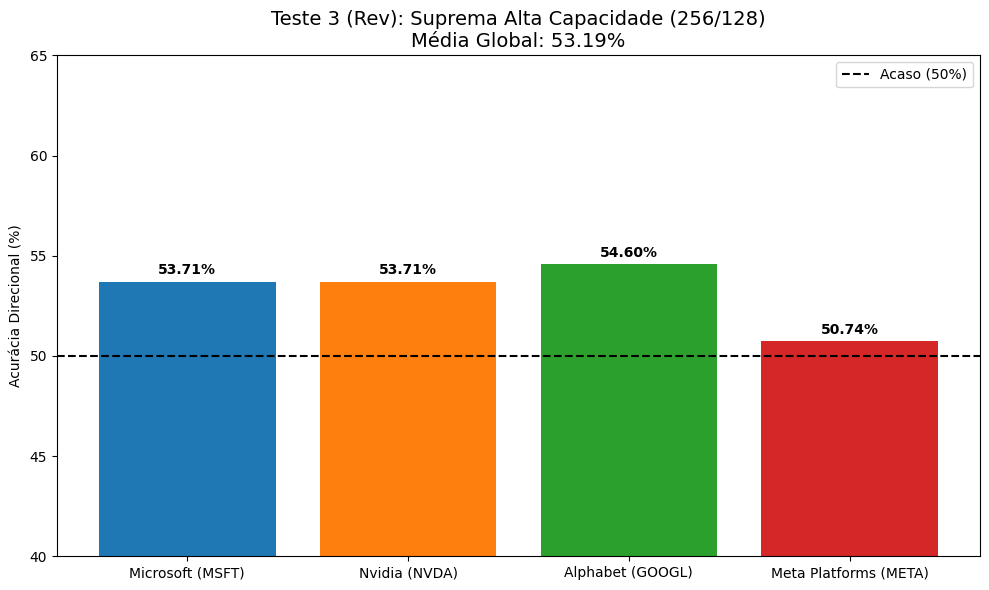

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware ativado para Teste de Alta Capacidade: {device}")

# 1. Coleta de Dados (O Megazord de 50 Variáveis)
tickers = ['MSFT', 'NVDA', 'GOOGL', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
ativos = ['MSFT', 'NVDA', 'GOOGL', 'META']

for ativo in ativos:
    df[f'{ativo}_Close'] = dados['Close'][ativo]

for ativo in ativos:
    df[f'{ativo}_Open']   = dados['Open'][ativo]
    df[f'{ativo}_High']   = dados['High'][ativo]
    df[f'{ativo}_Low']    = dados['Low'][ativo]
    df[f'{ativo}_Volume'] = dados['Volume'][ativo]

    close_ativo = df[f'{ativo}_Close']
    df[f'{ativo}_SMA_20'] = close_ativo.rolling(window=20).mean()
    df[f'{ativo}_EMA_20'] = close_ativo.ewm(span=20, adjust=False).mean()

    delta = close_ativo.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'{ativo}_RSI_14'] = 100 - (100 / (1 + (gain / loss)))

    exp1 = close_ativo.ewm(span=12, adjust=False).mean()
    exp2 = close_ativo.ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    df[f'{ativo}_MACD'] = macd
    df[f'{ativo}_MACD_Signal'] = macd.ewm(span=9, adjust=False).mean()

    std_20 = close_ativo.rolling(window=20).std()
    df[f'{ativo}_BB_Upper'] = df[f'{ativo}_SMA_20'] + (std_20 * 2)
    df[f'{ativo}_BB_Lower'] = df[f'{ativo}_SMA_20'] - (std_20 * 2)

df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df = df.dropna()
QTD_FEATURES = len(df.columns)
QTD_ALVOS = 4

# 2. Normalização e Preparação Binária
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

seq_len = 60 

def criar_sequencias_classificacao(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        preco_hoje = dados_array[i-1, 0:QTD_ALVOS]
        preco_amanha = dados_array[i, 0:QTD_ALVOS]
        alvo_binario = (preco_amanha > preco_hoje).astype(np.float32)
        y.append(alvo_binario)
    return np.array(X), np.array(y)

X, y = criar_sequencias_classificacao(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesClassificationDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesClassificationDataset(X_test, y_test), batch_size=32)

# 3. A Arquitetura Suprema (Com Alta Densidade Paramétrica)
class Classificador_Supremo_AltaCapacidade(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size, dropout_rate=0.2):
        super(Classificador_Supremo_AltaCapacidade, self).__init__()
        
        # Aumentamos a capacidade da Bi-LSTM
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Aumentamos a capacidade da Bi-GRU (recebe o dobro devido à Bi-LSTM)
        self.gru = nn.GRU(hidden_lstm * 2, hidden_gru, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc = nn.Linear(hidden_gru * 2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_lstm = self.dropout1(saida_lstm)
        
        saida_gru, _ = self.gru(saida_lstm)
        saida_gru = self.dropout2(saida_gru)
        
        logits = self.fc(saida_gru[:, -1, :])
        return self.sigmoid(logits)

# 4. A Maratona de Testes
N_RODADAS = 100 
todas_previsoes_probabilidades = []

print(f"\nTreinando {N_RODADAS} redes da Arquitetura Suprema (Bi-LSTM 256 + Bi-GRU 128)...")
print("Isto vai exigir mais processamento da sua placa de vídeo.")

for rodada in range(N_RODADAS):
    # Passando os novos valores de alta capacidade
    modelo = Classificador_Supremo_AltaCapacidade(
        input_size=QTD_FEATURES, 
        hidden_lstm=256, 
        hidden_gru=128, 
        output_size=QTD_ALVOS
    ).to(device)
    
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)
    criterion = nn.BCELoss() 
    
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            optimizer.zero_grad()
            probabilidades = modelo(pacotes_X.to(device))
            erro = criterion(probabilidades, pacotes_y.to(device))
            erro.backward()
            optimizer.step()
            
    modelo.eval()
    probabilidades_modelo = []
    with torch.no_grad():
        for pacotes_X, _ in test_loader:
            chute = modelo(pacotes_X.to(device))
            probabilidades_modelo.extend(chute.cpu().numpy())
            
    todas_previsoes_probabilidades.append(probabilidades_modelo)
    
    if (rodada + 1) % 10 == 0:
        print(f"  - {rodada+1}/{N_RODADAS} modelos concluídos.")

# 5. Cálculo das Métricas
media_probabilidades = np.mean(todas_previsoes_probabilidades, axis=0)
previsoes_finais_binarias = (media_probabilidades >= 0.5).astype(int)
alvos_reais_binarios = y_test.astype(int)

acuracias = []
nomes_ativos = ['Microsoft (MSFT)', 'Nvidia (NVDA)', 'Alphabet (GOOGL)', 'Meta Platforms (META)']

print("\n" + "="*50)
print(" RESULTADO DA ARQUITETURA SUPREMA DE ALTA CAPACIDADE")
print("="*50)

for i in range(QTD_ALVOS):
    acertos = np.sum(previsoes_finais_binarias[:, i] == alvos_reais_binarios[:, i])
    total = len(alvos_reais_binarios[:, i])
    acuracia = (acertos / total) * 100
    acuracias.append(acuracia)
    print(f"Acurácia {nomes_ativos[i]}: {acuracia:.2f}%")

print("-" * 50)
print(f"ACURÁCIA GLOBAL DO PORTFÓLIO: {np.mean(acuracias):.2f}%")
print("="*50)

# 6. Painel Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_ativos, acuracias, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='Acaso (50%)')
ax.set_ylabel('Acurácia Direcional (%)')
ax.set_title(f'Teste 3 (Rev): Suprema Alta Capacidade (256/128)\nMédia Global: {np.mean(acuracias):.2f}%', fontsize=14)
ax.set_ylim(40, 65) 

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}%',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()